model模型结构定义

In [1]:
import torch.nn as nn
import torch

class ResidualBlock1D(nn.Module):
    def __init__(self, dim, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim * 2)
        self.bn1 = nn.BatchNorm1d(dim * 2)
        self.fc2 = nn.Linear(dim * 2, dim)
        self.bn2 = nn.BatchNorm1d(dim)
        self.relu = nn.ReLU(inplace=True)

        # 添加更多dropout
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout * 1.5)  # 第二个dropout更大
        self.dropout_shortcut = nn.Dropout(dropout * 0.5)  # shortcut也加dropout

        # SE模块（可选的注意力）
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(dim, dim // 8),  # 缩小更多
            nn.ReLU(),
            nn.Linear(dim // 8, dim),
            nn.Sigmoid()
        ) if dim >= 32 else None

    def forward(self, x):
        residual = x

        out = self.fc1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout1(out)

        out = self.fc2(out)
        out = self.bn2(out)

        # SE模块
        if self.se is not None:
            se_weight = self.se(out.unsqueeze(-1)).unsqueeze(-1)
            out = out * se_weight.squeeze(-1)

        # Shortcut dropout（随机丢弃残差连接）
        residual = self.dropout_shortcut(residual)

        out = self.relu(out + residual)
        out = self.dropout2(out)
        return out


class ResNet1D(nn.Module):
    def __init__(self, input_dim=400, num_classes=2, hidden_dims=[512, 256, 128, 64]):
        super().__init__()
        
        # 输入投影
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]),
            nn.BatchNorm1d(hidden_dims[0]),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1)
        )
        
        # 多尺度特征提取
        self.blocks = nn.ModuleList([
            nn.Sequential(
                ResidualBlock1D(hidden_dims[0], dropout=0.1),
                ResidualBlock1D(hidden_dims[0], dropout=0.1)
            ),
            nn.Sequential(
                nn.Linear(hidden_dims[0], hidden_dims[1]),
                nn.BatchNorm1d(hidden_dims[1]),
                nn.ReLU(inplace=True),
                ResidualBlock1D(hidden_dims[1], dropout=0.15),
                ResidualBlock1D(hidden_dims[1], dropout=0.15)
            ),
            nn.Sequential(
                nn.Linear(hidden_dims[1], hidden_dims[2]),
                nn.BatchNorm1d(hidden_dims[2]),
                nn.ReLU(inplace=True),
                ResidualBlock1D(hidden_dims[2], dropout=0.2),
                ResidualBlock1D(hidden_dims[2], dropout=0.2)
            )
        ])
        
        # 全局特征融合
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        
        # 分类头
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dims[2] * 2, hidden_dims[3]),  # 拼接全局和局部特征
            nn.BatchNorm1d(hidden_dims[3]),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(hidden_dims[3], num_classes)
        )
        
        # 辅助分类器（可选）
        self.aux_classifier = nn.Linear(hidden_dims[2], num_classes)
        
    def forward(self, x, return_features=False):
        # 输入投影
        x = self.input_proj(x)
        
        # 多尺度特征
        features = []
        for block in self.blocks:
            x = block(x)
            features.append(x)
        
        # 全局特征
        global_feat = self.global_pool(x.unsqueeze(-1)).squeeze(-1)
        
        # 局部特征（最后一个block的输出）
        local_feat = x
        
        # 特征融合
        combined = torch.cat([global_feat, local_feat], dim=1)
        
        # 分类
        out = self.classifier(combined)
        
        if return_features:
            return out, combined
        return out

数据读取定义

In [2]:
import torch
from datasets import Dataset, DatasetDict, IterableDatasetDict, load_dataset

def prepare_dataset():

    dataset = load_dataset(
        'csv',
        data_files={"test": "/home/user/prognosis_lst/evaluate_model/ConvNeXt/data/huaxi/val/final_complete_with_paths_labels.csv"}
    )

    feature_path = "feature_path"
    labels_name = "label"
    
    def preprocess(examples):
        features = [torch.load(feature, weights_only=True) for feature in examples[feature_path]]

        normalized_features = []
        for feature in features:
            normalized = (feature - 0.5) / 0.5  # 映射到 [-1, 1]
            normalized_features.append(normalized)

        examples["features"] = normalized_features
        return examples

    test_dataset = dataset["test"].with_transform(preprocess)


    def collate_fn(examples):
        features = torch.stack([example["features"] for example in examples])
        features = features.to(memory_format=torch.contiguous_format).float()
        labels = [example[labels_name] for example in examples]
        return {"features": features,"labels": labels}

    sampler_test = torch.utils.data.SequentialSampler(test_dataset)

    data_loader_test = torch.utils.data.DataLoader(
        test_dataset,
        sampler=sampler_test,
        collate_fn=collate_fn,
        batch_size=10,
        num_workers=4,
        pin_memory=True,
        drop_last=False
    )

    return data_loader_test, len(test_dataset)


In [3]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score

# --- 用户配置区 ---
CONFIG = {
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "save_plot_dir": "/home/user/prognosis_lst/evaluate_model/plot/DCA曲线/huaxi"
}

os.makedirs(CONFIG["save_plot_dir"], exist_ok=True)
device = torch.device(CONFIG["device"])

# 假设你的 test_dataloader 已经定义为：test_loader
# 假设你的模型类已经定义为：YourModelClass (例如 UNet)

In [4]:
def run_evaluation(model_instance, ckpt_path, dataloader, device):

    if not os.path.exists(ckpt_path):
        print(f"⚠️ 警告：找不到权重文件 {ckpt_path}")
        return None, None

    ckpt = torch.load(ckpt_path, map_location='cpu')
    state_dict = ckpt["model"] if "model" in ckpt else ckpt
    # 移除可能存在的 model. 前缀
    new_state_dict = {k.replace('model.', ''): v for k, v in state_dict.items()}
    

    model_instance.load_state_dict(new_state_dict, strict=True)
    model_instance.to(device)
    model_instance.eval()
    print(f"✅ 成功加载权重: {ckpt_path}")

    all_scores = [] # 存储正类概率 (pos_probs)
    all_labels = [] # 存储真实标签

    with torch.no_grad():
        # 使用 tqdm 替代 metric_logger 方便在 Jupyter 查看进度
        for batch in tqdm(dataloader, desc="正在推理", leave=False):
            images = batch["features"].to(device, non_blocking=True)
            raw_labels = batch["labels"]
            if isinstance(raw_labels, torch.Tensor):
                labels = raw_labels.to(device, non_blocking=True)
            else:
                # 如果是列表且里面是数字，转为 Tensor
                # 如果里面是字符串路径，这一行会报错，说明你需要找真正的数字标签 Key
                labels = torch.tensor(raw_labels).to(device)
    
            # 2. 前向传播 (参考 test 函数)
            output = model_instance(images)
            probs = torch.softmax(output, dim=1) # 得到所有类别的概率

            pos_probs = probs[:, 1] 
            
            all_scores.append(pos_probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    # 4. 合并数据
    y_score = np.concatenate(all_scores).flatten()
    y_true = np.concatenate(all_labels).flatten()
    
    # 返回真值和预测概率
    return y_true, y_score

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def plot_dca(results_list, model_name, save_dir=CONFIG["save_plot_dir"]):

    plt.figure(figsize=(7, 7), dpi=100)
    
    # 自动配色方案（与ROC一致，使用Spectral）
    cmap = plt.get_cmap('Spectral')
    colors = cmap(np.linspace(0, 1, len(results_list)))
    
    # 阈值范围
    thresholds = np.linspace(0, 0.99, 100)
    
    for i, res in enumerate(results_list):
        y_true = np.array(res['y_true']).astype(float).astype(int)
        y_prob = np.array(res['y_score']).astype(float)
        n = len(y_true)
        
        net_benefit_model = []
        
        for t in thresholds:
            y_pred = (y_prob >= t).astype(int)
            tp = np.sum((y_pred == 1) & (y_true == 1))
            fp = np.sum((y_pred == 1) & (y_true == 0))
            
            # 净获益公式
            if t == 0:
                nb = (tp / n) - (fp / n) * 0  # 避免除以0
            else:
                nb = (tp / n) - (fp / n) * (t / (1 - t))
            net_benefit_model.append(nb)
        
        # 绘制模型曲线
        plt.plot(thresholds, net_benefit_model, color=colors[i], lw=2,
                 label=f"{res['label']}")
    

    if len(results_list) > 0:
        y_true_first = np.array(results_list[0]['y_true']).astype(float).astype(int)
        n_first = len(y_true_first)
        tp_all = np.sum(y_true_first == 1)
        fp_all = np.sum(y_true_first == 0)
        
        net_benefit_all = []
        for t in thresholds:
            if t == 0:
                nb_all = (tp_all / n_first) - (fp_all / n_first) * 0
            else:
                nb_all = (tp_all / n_first) - (fp_all / n_first) * (t / (1 - t))
            net_benefit_all.append(nb_all)
        
        plt.plot(thresholds, net_benefit_all, color='black', lw=1.5, 
                 linestyle='--', label='Treat All')
    
    # 绘制 "Treat None" 曲线（净获益恒为0）
    plt.plot(thresholds, [0]*len(thresholds), color='grey', lw=1.5, 
             linestyle='--', label='Treat None')
    
    max_nb = max([max(np.array(nb)) for nb in [net_benefit_model] + [net_benefit_all]] if results_list else [0])
    plt.ylim(-0.05, max(max_nb * 1.2, 0.5))
    plt.xlim([0.0, 1.0])
    
    plt.xlabel('Threshold Probability', fontsize=13)
    plt.ylabel('Net Benefit', fontsize=13)
    plt.title(f'Decision Curve Analysis of the Huaxi Dataset', fontsize=14)
    plt.legend(loc='best', frameon=True, fontsize=10)
    plt.grid(alpha=0.2)
    plt.tight_layout()
    
    # 保存图片
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        save_path = os.path.join(save_dir, f"{model_name}_dca.png")
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"💾 图表已保存至: {save_path}")
    
    plt.show()

正在处理模型: resnet


/tmp/ipykernel_2064962/3683528652.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location='cpu')


✅ 成功加载权重: /home/user/prognosis_lst/evaluate_model/ConvNeXt/output/huaxi/pull_strength/pull_strength_pull_0.75/generate/checkpoint-best.pth


正在推理:   0%|          | 0/11 [00:00<?, ?it/s]

💾 图表已保存至: /home/user/prognosis_lst/evaluate_model/plot/DCA曲线/huaxi/resnet_dca.png


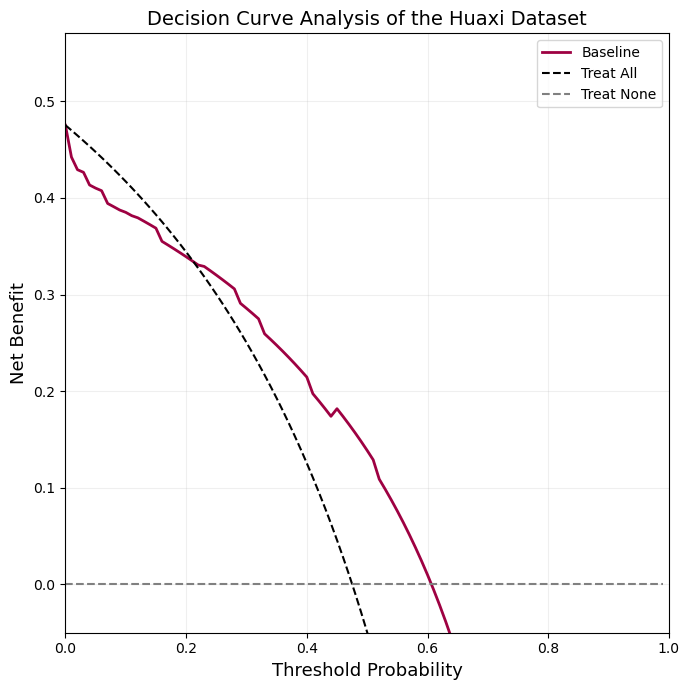

In [8]:
# --- 运行区 ---
# 1. 实例化你的模型（请替换为你自己的模型类名）
model = ResNet1D()
data_loader_test, len_dataset_test = prepare_dataset()
# 2. 定义你想对比的模型和权重路径
eval_configs = {
    "resnet": [
        {"label": "Baseline", "path":"/home/user/prognosis_lst/evaluate_model/ConvNeXt/output/huaxi/pull_strength/pull_strength_pull_0.75/generate/checkpoint-best.pth"},
    ],
    # 如果有其他模型可以继续添加...
}

summary_table = []

for m_name, weights in eval_configs.items():
    print(f"正在处理模型: {m_name}")
    model_plot_data = []
    

    for w_config in weights:
        y_true, y_score = run_evaluation(model, w_config["path"], data_loader_test,"cuda") # 使用你定义好的 test_loader
        
        if y_true is not None:
            # 计算 Dice 等指标用于汇总表
            bin_preds = (y_score > 0.5).astype(np.uint8)
            intersection = np.logical_and(bin_preds, y_true).sum()
            dice = (2. * intersection) / (bin_preds.sum() + y_true.sum() + 1e-6)
            
   
            
            model_plot_data.append({
                "label": w_config["label"],
                "y_true": y_true,
                "y_score": y_score
            })
    
    # 为当前模型绘制对比图
    if model_plot_data:
        plot_dca(model_plot_data, m_name)

